In [1]:
# Load libraries
import pandas as pd # data manipulation
import numpy as np # vectorized math


In [2]:
# view training data set 

df = pd.read_csv('/Users/juskiiii/titanic/Data/train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# view shape info
df.shape

(891, 12)

In [4]:
# duplicate info count 
df.duplicated().sum()

0

In [5]:
# review data types (helps avoids data mining issue later downstream)
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
# check for null values 
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# remove null values (In this cell, instead of removing nan values we will turn the column into a signal itself -> "Unkwnown")

df['Cabin'] = df['Cabin'].fillna('Unknown')

In [8]:
# replace null values with average age (mean)

mean = df['Age'].mean().astype(int)

df['Age'] = df['Age'].fillna(mean)

In [9]:
 # replace null values with most frequent qualatative value (mode)

mode = df['Embarked'].value_counts().max()

df['Embarked'] = df['Embarked'].fillna(mode)

In [10]:
# check results of null removal

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [11]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unknown,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.0,1,2,W./C. 6607,23.4500,Unknown,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [12]:
# remove "Name" column 
df = df.drop(columns = ['Name'])

In [13]:
# summary statistics 
df.describe(include=['number']).T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.560236,13.005010,0.42,22.0000,29.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [14]:
#                                   --- Visualization Phase--- 
import seaborn as sns 
import matplotlib.pyplot as plt

<Axes: >

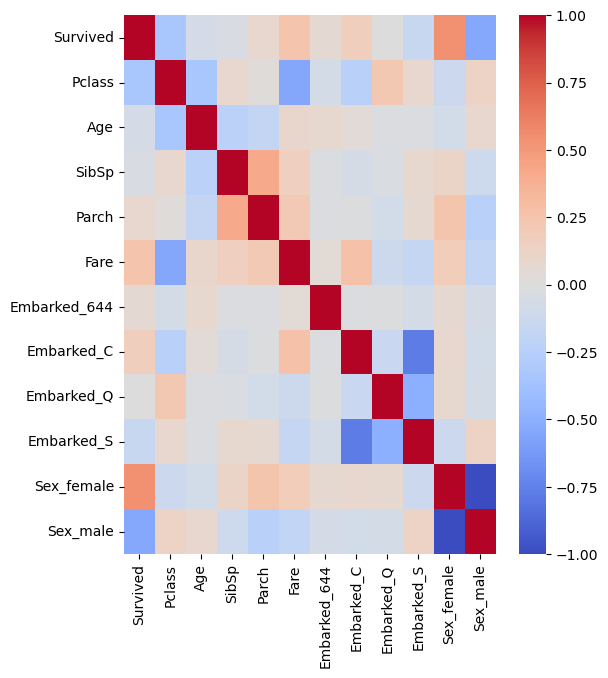

In [15]:
# Create a correlation heatmap

# drop the ID column... this variable has no use in training, will effect the visualization 
df1 = df.drop(columns= ['PassengerId']) 

# Create boolean columns for categorical features 
df2 = pd.get_dummies(df[['Embarked', 'Sex']])

# merge boolean dataframe with original
df1 = df1.merge(df2, left_index= True, right_index= True)

# compute correlation matrix for numeric values only 
corr = df1.select_dtypes(include = ['number', 'bool']).corr() # grab all numbers and boolean columns and store into corr object

# create map
plt.figure(figsize= (6,7)) # visualization size 
sns.heatmap(corr, annot = False, cmap= 'coolwarm', fmt = '.2f' ) # correation matrix plot 

In [16]:
# numeric correlation
df1.corr(numeric_only= True)

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
Survived,1.000000,-0.338481,-0.067814,-0.035322,0.081629,0.257307,0.060095,0.168240,0.003650,-0.155660,0.543351,-0.543351
Pclass,-0.338481,1.000000,-0.334974,0.083081,0.018443,-0.549500,-0.074282,-0.243292,0.221009,0.081720,-0.131900,0.131900
Age,-0.067814,-0.334974,1.000000,-0.232978,-0.176486,0.093706,0.074589,0.031303,-0.021093,-0.021999,-0.082949,0.082949
SibSp,-0.035322,0.083081,-0.232978,1.000000,0.414838,0.159651,-0.022508,-0.059528,-0.026354,0.070941,0.114631,-0.114631
Parch,0.081629,0.018443,-0.176486,0.414838,1.000000,0.216225,-0.022467,-0.011069,-0.081228,0.063036,0.245489,-0.245489
Fare,0.257307,-0.549500,0.093706,0.159651,0.216225,1.000000,0.045646,0.269335,-0.117216,-0.166603,0.182333,-0.182333
Embarked_644,0.060095,-0.074282,0.074589,-0.022508,-0.022467,0.045646,1.000000,-0.022864,-0.014588,-0.076588,0.064296,-0.064296
Embarked_C,0.168240,-0.243292,0.031303,-0.059528,-0.011069,0.269335,-0.022864,1.000000,-0.148258,-0.778359,0.082853,-0.082853
Embarked_Q,0.003650,0.221009,-0.021093,-0.026354,-0.081228,-0.117216,-0.014588,-0.148258,1.000000,-0.496624,0.074115,-0.074115
Embarked_S,-0.155660,0.081720,-0.021999,0.070941,0.063036,-0.166603,-0.076588,-0.778359,-0.496624,1.000000,-0.125722,0.125722


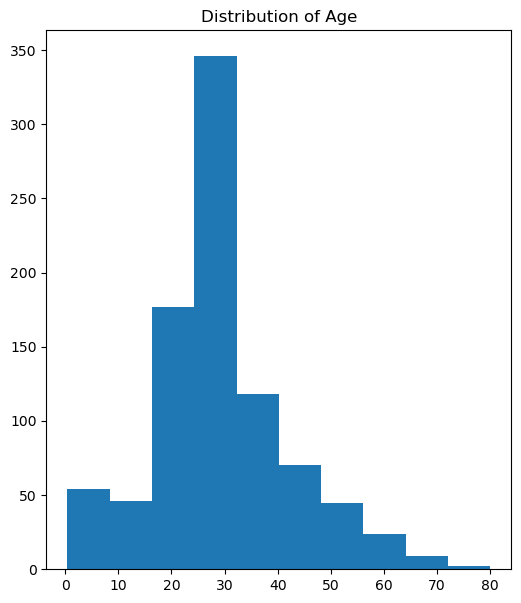

In [17]:
# distrbution of age 
plt.figure(figsize=(6,7))
plt.hist(x= df['Age'], density= False, )
plt.title('Distribution of Age')
plt.show() 

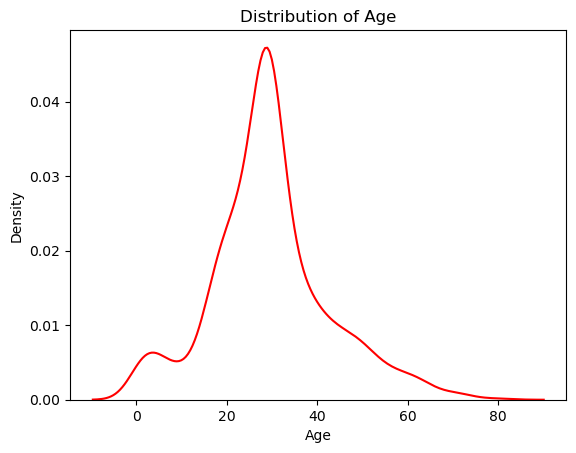

In [18]:
# Distribution of Age with smooth =
sns.kdeplot(data = df1, x = 'Age', color= 'red')
plt.title('Distribution of Age')
plt.show()

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

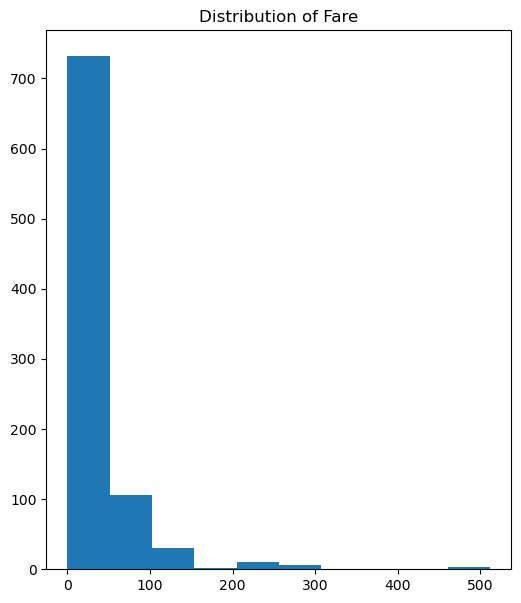

In [19]:
# Distribution of Fare (Passenger Price)
plt.figure(figsize=(6,7)) 
plt.hist(x = df1['Fare'], density= False)
plt.title('Distribution of Fare')
plt.title

<Axes: xlabel='Fare', ylabel='Density'>

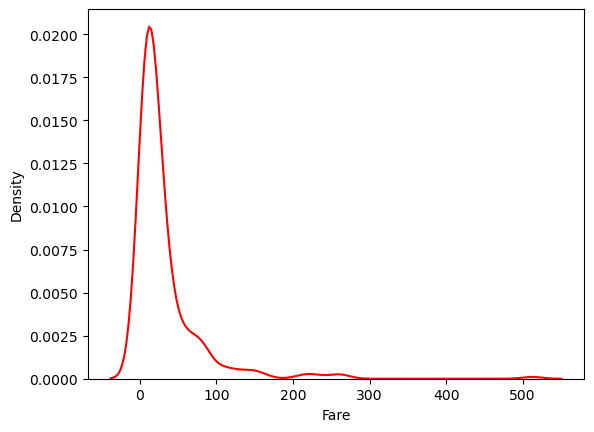

In [20]:
# Distribution of Fare with smoothing 
sns.kdeplot(df1, x = 'Fare', color = 'red')

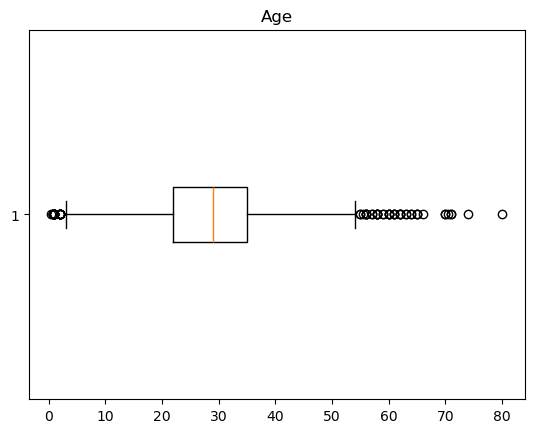

In [21]:
# Look for high leverage data plots within input variables 

# whisker plot 
plt.boxplot(df1['Age'], vert = False)
plt.title('Age')
plt.show()

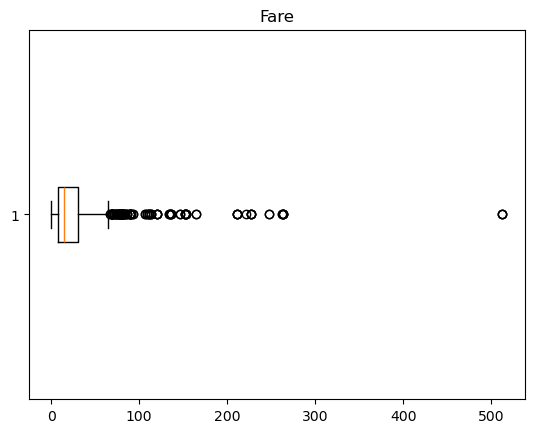

In [22]:
# Look for high leverage values in X 

# boxplot 
plt.boxplot(df1['Fare'], vert = False)
plt.title("Fare")
plt.show()

In [23]:
# The Fare varibale has data points far from the residual 
# To avoid the regression line being pull towards them and distorting the decision boudary, I will log transform the columns indiviually

# Fare log transformation 
df1['Fare'] = np.log1p(df1['Fare'])


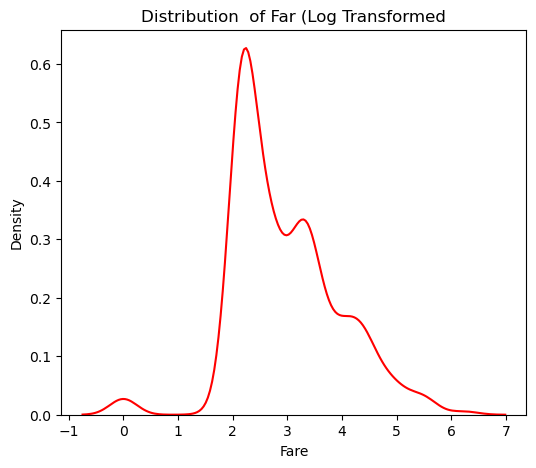

In [24]:
# View distribution for Fare variable 
plt.figure(figsize= (6,5)) 
sns.kdeplot(data = df1, x = 'Fare', color= 'red')
plt.title('Distribution  of Far (Log Transformed')
plt.show()

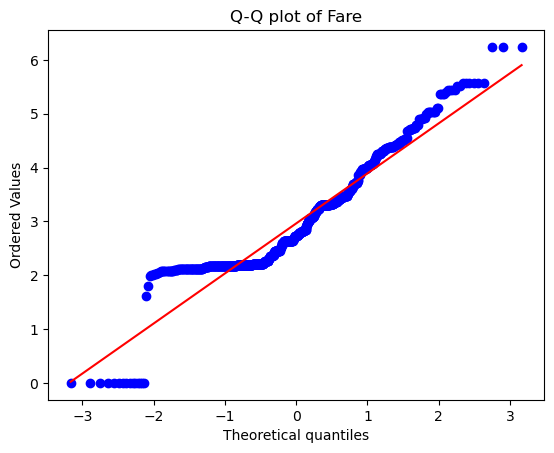

In [25]:
# Let's view the plot using a Q-Q plot 

import scipy.stats as stats
stats.probplot(df1['Fare'], dist = 'norm', plot = plt)
plt.title('Q-Q plot of Fare')
plt.show()

In [26]:
# Class Balance of the target Variable (Survived)
df[['Survived']].value_counts()

Survived
0           549
1           342
Name: count, dtype: int64

In [27]:
# turn high cardinality varibles into meaningful patterns
# Model can learn from the categories based on the mean of each category coupled with the target variable 

from sklearn.preprocessing import TargetEncoder # library 

# intialize encoder (including cross validation prohibits data leakage)
encoder = TargetEncoder(smooth = 'auto', cv = 5, shuffle = True, random_state= 42)

# store variables into X and Y obejects
X = df1[['Cabin']]
Y = df1['Survived']

# fit to transform 
df1['Cabin_encoded'] = encoder.fit_transform(X, Y)

In [28]:
# scale numerical values (This is leads to model converging much faster)
from sklearn.preprocessing import StandardScaler

# create instance
scaler = StandardScaler()

# store columns in a object
X = df1[['Age']]
X1 = df1[['Fare']]

# fit to transform columns
df1['Age'] = scaler.fit_transform(X)
df1['Fare'] = scaler.fit_transform(X1)

In [29]:
# remove ticket number column (Weak or meanless variable)
df1 = df1.drop(columns=['Ticket'])

In [30]:
# remove uneccesary columns (Stings won't fit in training downstream)
df1 = df1.drop(columns=['Sex'])
df1 = df1.drop(columns=['Cabin'])
df1 = df1.drop(columns=["Embarked"])

In [31]:
df1

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Cabin_encoded
0,0,3,-0.581659,1,0,-0.879741,False,False,False,True,False,True,0.303217
1,1,1,0.649327,1,0,1.361220,False,True,False,False,True,False,0.382889
2,1,3,-0.273913,0,0,-0.798540,False,False,False,True,True,False,0.298863
3,1,1,0.418517,1,0,1.062038,False,False,False,True,True,False,0.000000
4,0,3,0.418517,0,0,-0.784179,False,False,False,True,False,True,0.303215
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,-0.196976,0,0,-0.333698,False,False,False,True,False,True,0.297779
887,1,1,-0.812469,0,0,0.487082,False,False,False,True,True,False,0.384292
888,0,3,-0.043103,1,2,0.242007,False,False,False,True,True,False,0.298863
889,1,1,-0.273913,0,0,0.487082,False,True,False,False,False,True,0.384292


In [32]:
# Feature Engineneering Phase
# (Later we will test t-test coefficients to view if feature is statistically significant in predicting target)

# Interaction features  
df1['interaction1'] = (df1['SibSp'] * df1['Parch'])
df1['interaction2'] = (df1['SibSp'] * df1['Fare'])
df1['interaction3'] = (df1['Parch'] * df1['Fare'])
df1['interaction4'] = (df1['Age'] * df1['Fare'])
df1['interaction5'] = (df1['Pclass'] * df1['Fare'])
df1['interaction6'] = (df1['Sex_female'] * df1['Fare'])
df1['interaction7'] = (df1['Sex_male'] * df1['Fare'])


# Ratio Features 
df1['Ratio1'] = (df1['Age'] / df1['Fare'])
df1['Ratio2'] = (df1['SibSp'] / df1['Fare'])
df1['Ratio3'] = (df1['Parch'] / df1['Fare'])
df1['Ratio4'] = (df1['Sex_female'] / df1['Fare'])
df1['Ratio5'] = (df1['Sex_male'] / df1['Fare'])





In [ ]:
# save the dataset with engineered features to CSV
df1.to_csv('../features.csv', index=False)

In [42]:
# Training Phase 
# Import the testing data recieved from the kaggle
test = pd.read_csv('/Users/juskiiii/titanic/Data/test.csv')

# import neccessary library from sklearn
from sklearn.

SyntaxError: invalid syntax (3470449113.py, line 6)

In [ ]:
# Modeling Phase (Classification)
from sklearn.linear_model import LinearRegression
